In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['font.family'] = ['Arial', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
RNG = np.random.default_rng(20260926)

MODELS = [
    ("KGML-Graph", 1.109, 0.761, 0.784, 1.770, -0.074, 8.55),
    ("LSTM", 1.315, 0.665, 0.692, 2.838, -0.413, 8.15),
    ("GRU", 1.324, 0.660, 0.657, 3.179, -0.482, 8.65),
    ("TempCNN", 1.524, 0.550, 0.652, 3.274, -0.537, 10.70),
]


HEXBIN_CMAP = LinearSegmentedColormap.from_list(
    "my_cmap",
    [
        "#F4FBF8",
        "#E1F3EC",
        "#C3E6D9",
        "#91D1BD",
        "#5DB79D",
        "#2D9478",
        "#096B52",
    ],
    N=256,
)

MARGINAL_COLOR = "#69BFA8"
REG_COLOR = "#B74B4B"
REF_COLOR = "#222222"
RESID_COLOR = "#8A8A8A"
BIAS_COLOR = "#A83F3F"


# plt.rcParams.update({
#     "font.family": "DejaVu Sans",
#     "font.size": 10,
#     "axes.labelsize": 11,
#     "axes.titlesize": 12,
#     "axes.linewidth": 1.0,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
#     "figure.facecolor": "white",
#     "axes.facecolor": "white",
#     "savefig.facecolor": "white",
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
#     "svg.fonttype": "none",
# })

## 模拟数据

In [3]:
def make_data(rmse, r2, slope, intercept, target_bias,
              x_mean, n=15000, seed=0):
    """仅用于视觉复现的模拟数据，不是原始数据。"""
    rng = np.random.default_rng(seed)

    # 参考值分布
    x = rng.normal(x_mean, 1.55, n)
    x = np.clip(x, 1.0, 13.8)

    # 根据 R² 调整噪声水平
    sigma = (0.68 if r2 >= 0.70 else 0.88)
    sigma *= (
        0.72
        + 0.045 * np.abs(x - x_mean)
        + 0.045 * (x / 10)
    )

    y = intercept + slope * x + rng.normal(0, sigma, n)

    # 增加少量外围样本
    halo = rng.random(n) < 0.14
    y[halo] += rng.normal(0, 0.75, halo.sum())

    keep = (
        (x >= 0) & (x <= 14) &
        (y >= 0) & (y <= 14)
    )
    x, y = x[keep], y[keep]

    # 修正残差均值
    residual = y - x
    y += target_bias - residual.mean()

    keep = (y >= 0) & (y <= 14)
    return x[keep], y[keep]

## 制图

In [4]:
def add_marginals(ax, x, y):
    """添加顶部和右侧边缘直方图。"""

    top = ax.inset_axes(
        [0.0, 1.005, 1.0, 0.115],
        sharex=ax
    )

    right = ax.inset_axes(
        [1.005, 0.0, 0.115, 1.0],
        sharey=ax
    )

    bins = np.linspace(0, 14, 31)

    top.hist(
        x,
        bins=bins,
        color=MARGINAL_COLOR,
        alpha=0.68,
        edgecolor=MARGINAL_COLOR,
        linewidth=0.25,
    )

    right.hist(
        y,
        bins=bins,
        orientation="horizontal",
        color=MARGINAL_COLOR,
        alpha=0.68,
        edgecolor=MARGINAL_COLOR,
        linewidth=0.25,
    )

    top.set_xlim(0, 14)
    right.set_ylim(0, 14)

    top.axis("off")
    right.axis("off")


def add_residual_inset(ax, residual):
    """添加右下角 residual histogram。"""

    inset = ax.inset_axes(
        [0.49, 0.08, 0.49, 0.38]
    )

    bins = np.linspace(-6.2, 6.2, 28)

    inset.hist(
        residual,
        bins=bins,
        color=RESID_COLOR,
        edgecolor="white",
        linewidth=0.55,
        alpha=0.85,
    )

    bias = residual.mean()

    inset.axvline(
        bias,
        color=BIAS_COLOR,
        linestyle="--",
        linewidth=1.8,
        ymin=0,
        ymax=1.1,
    )

    # 使用数据坐标放置数值，避免与标题重叠
    ymax = inset.get_ylim()[1]

    inset.text(
        bias + 0.12,
        ymax * 1.05,
        f"{bias:+.3f}",
        ha="left",
        va="top",
        fontsize=8.5,
        color="#555555",
    )

    inset.set_xlim(-6.2, 6.2)
    inset.set_xticks([-6, -4, -2, 0, 2, 4, 6])
    
    
    inset.spines["left"].set_visible(False)
    inset.spines["right"].set_visible(False)
    inset.spines["top"].set_visible(False)

    inset.set_xlabel(
        "Residual",
        fontsize=8.5,
        labelpad=-1,
    )

    inset.set_yticklabels([])

    inset.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=2.5,
        width=0.75,
        labelsize=7.5,
        pad=1.5,
    )

    inset.tick_params(axis="y", length=0)

    for spine in inset.spines.values():
        spine.set_linewidth(0.85)
        spine.set_color("#333333")

    inset.set_facecolor("none")
    inset.patch.set_alpha(0.0)


def plot_panel(ax, name, rmse, r2, slope, intercept, target_bias, x_mean, cmap, seed):

    x, y = make_data(rmse, r2, slope, intercept, target_bias, x_mean, seed=seed)


    # gridsize：横向六边形数量。
    # mincnt=1：不显示空 bin。
    # bins='log'：用 log(count) 映射颜色，使高密度核心和外围低密度区域同时具有较好的可见度。
    # linewidths=0：去掉六边形边界，形成原图那种连续蜂窝云。
    hb = ax.hexbin(
        x,
        y,
        gridsize=50,
        extent=(0, 14, 0, 14),
        mincnt=1,
        bins="log",
        cmap=cmap,
        linewidths=0,
        edgecolors="none",
        alpha=1,
        zorder=2,
        rasterized=True,
    )

    # 1:1 reference line
    ax.plot(
        [0, 14],
        [0, 14],
        color=REF_COLOR,
        linewidth=1.15,
        zorder=5,
    )

    # Linear regression
    xx = np.array([1.2, 13.0])
    yy = intercept + slope * xx

    ax.plot(
        xx,
        yy,
        color=REG_COLOR,
        linewidth=2.0,
        zorder=6,
    )

    # 边缘直方图
    add_marginals(ax, x, y)


    ax.set_xlim(0, 14)
    ax.set_ylim(0, 14)
    ax.set_aspect("equal", adjustable="box")
    ticks = np.arange(0, 15, 2)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.grid(
        True,
        color="#D9DEDC",
        linewidth=0.55,
        alpha=1,
        zorder=1,
    )
    ax.set_xlabel(
        "Reference label (t/ha)",
        labelpad=4,
    )
    ax.set_ylabel(
        "Estimated yield (t/ha)",
        labelpad=4,
    )

    # Title
    ax.set_title(
        name,
        fontsize=12.5,
        fontweight="normal",
        pad=33,
    )


    # Metrics
    ax.text(
        0.065,
        0.93,
        f"RMSE: {rmse:.3f}\n"
        rf"$R^2$: {r2:.3f}" "\n"
        f"Slope: {slope:.3f}\n"
        f"Intercept: {intercept:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.5,
        linespacing=1.32,
        color="#202020",
        zorder=10,
    )

    # Residual
    add_residual_inset(
        ax,
        y - x,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.05)
        spine.set_color("#333333")

    return x, y

In [5]:
colors = {
    0: ["#F7F8F9", "#E8EBEE", "#D6DCE1", "#C0C9D0", "#A7B3BC",
              "#8B99A3", "#6E7D88", "#52616D", "#374852"],
    1: ["#F2F7FB", "#DCEAF5", "#C1DDED", "#A4CDE1", "#84BBD4",
              "#63A6C4", "#478EAE", "#347592", "#235B77"],
    2: ["#F6F8F5", "#E7ECE4", "#D5DED1", "#C0CEC0", "#A7BAAA",
              "#8FA696", "#718C7C", "#536F60", "#365445"],
    3: ["#FAF3ED", "#F1DED2", "#E5C4B4", "#D7A795", "#C88B77",
              "#B76F5D", "#A05445", "#843D35", "#682D2B"],
}

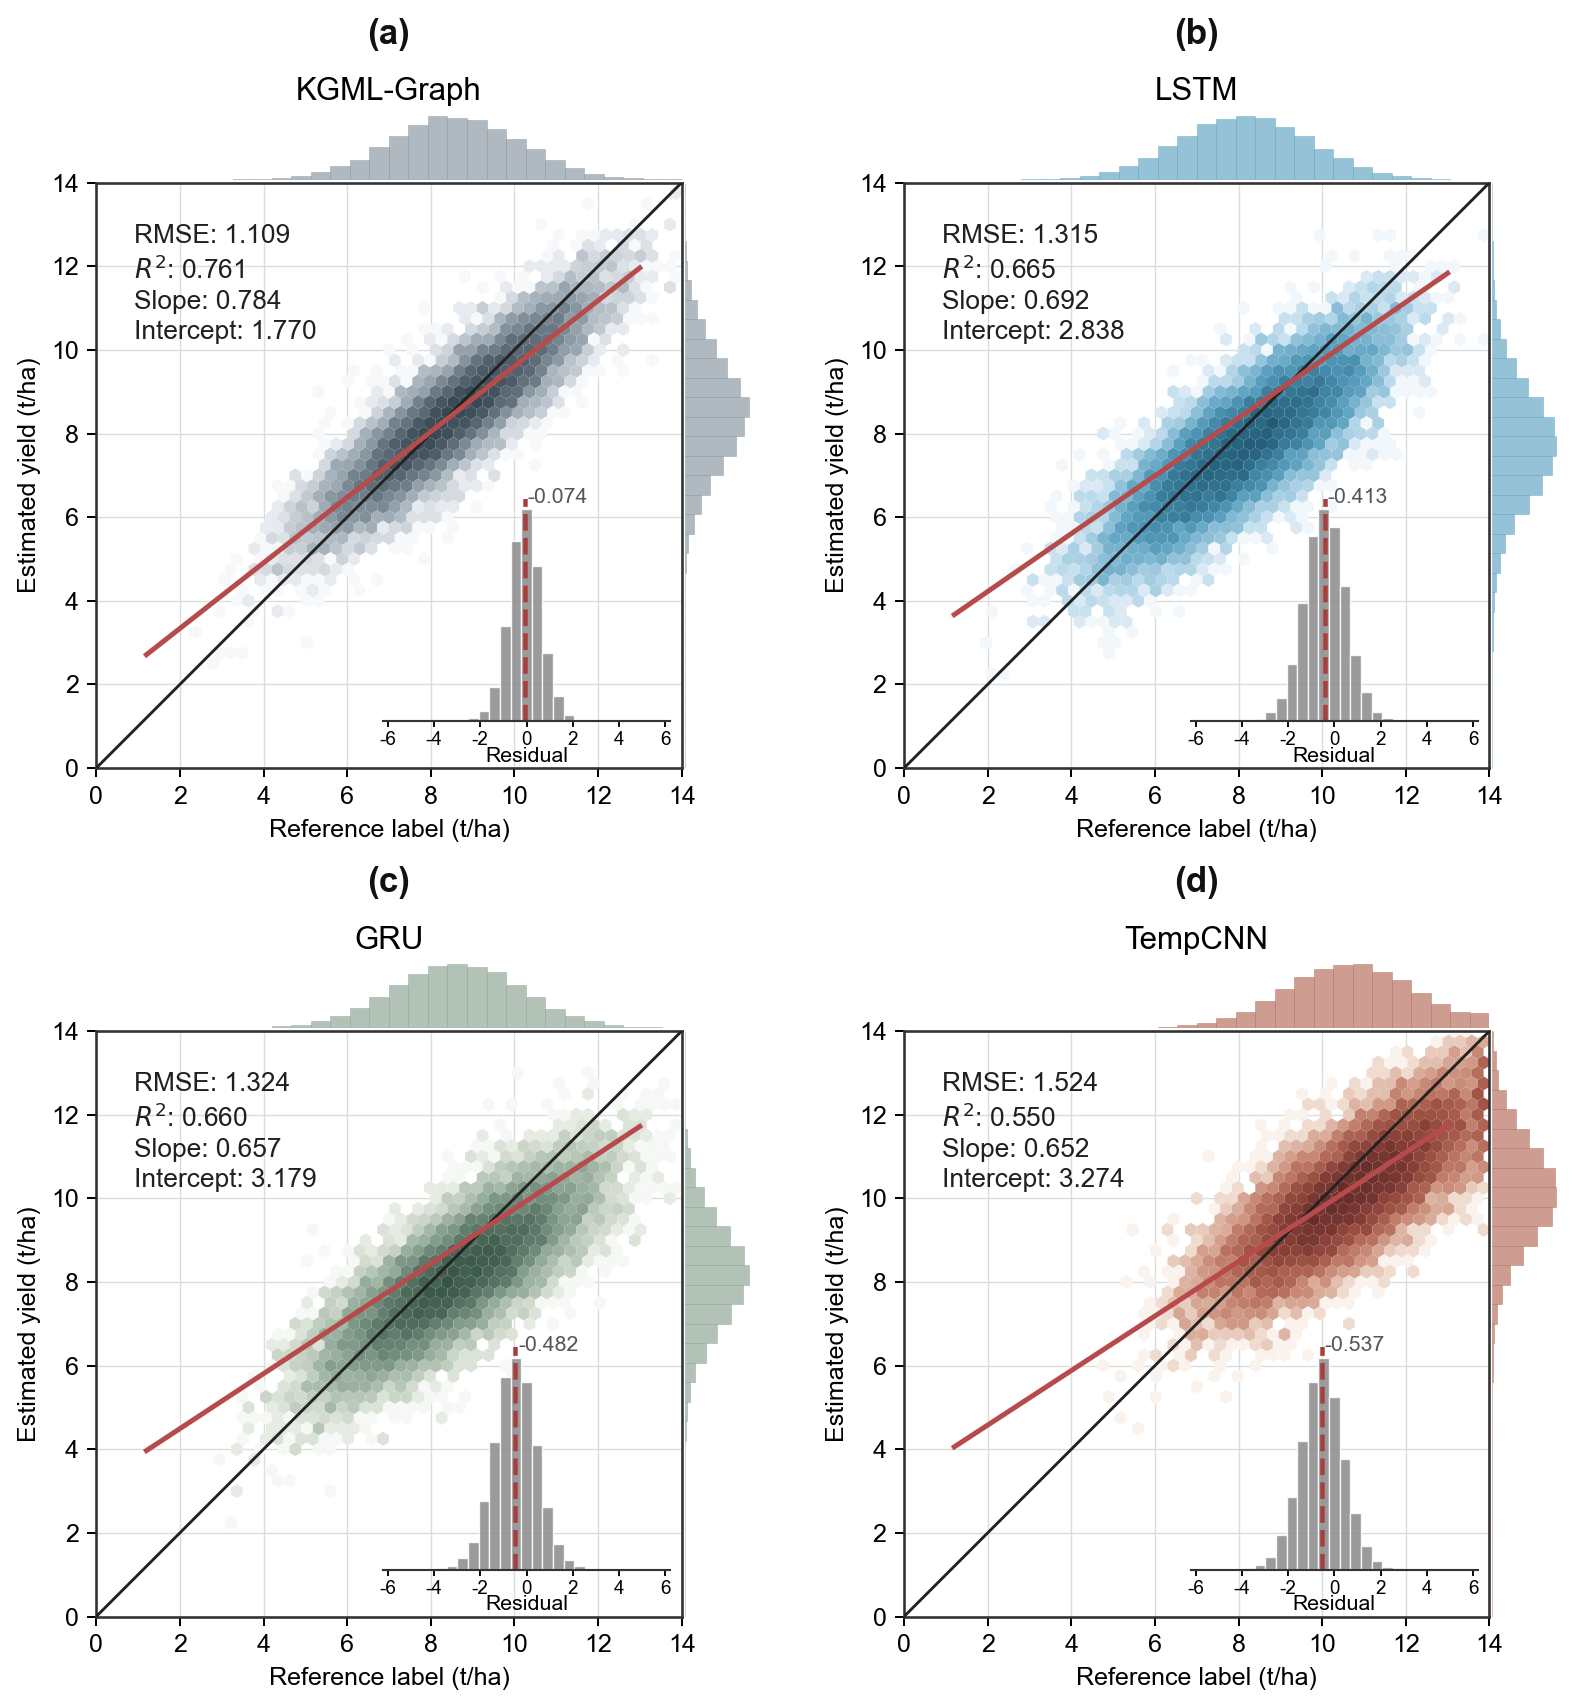

In [6]:
fig = plt.figure(
    figsize=(9.0, 9.0),
    dpi=180,
)

gs = fig.add_gridspec(
    2,
    2,
    left=0.075,
    right=0.935,
    bottom=0.075,
    top=0.965,
    wspace=0.38,
    hspace=0.43,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for i, (ax, label, params) in enumerate(
    zip(axes, panel_labels, MODELS)
):
    MARGINAL_COLOR = colors[i][5]
    HEXBIN_CMAP = LinearSegmentedColormap.from_list(
        name="my_cmap",
        colors=colors[i],
        N=256
    )

    plot_panel(
        ax,
        *params,
        cmap=HEXBIN_CMAP,
        seed=100 + i,
    )

    ax.text(
        0.5,
        1.225,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        color="#111111",
    )


fig.savefig(
    "HEXBIN.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
)
plt.show()

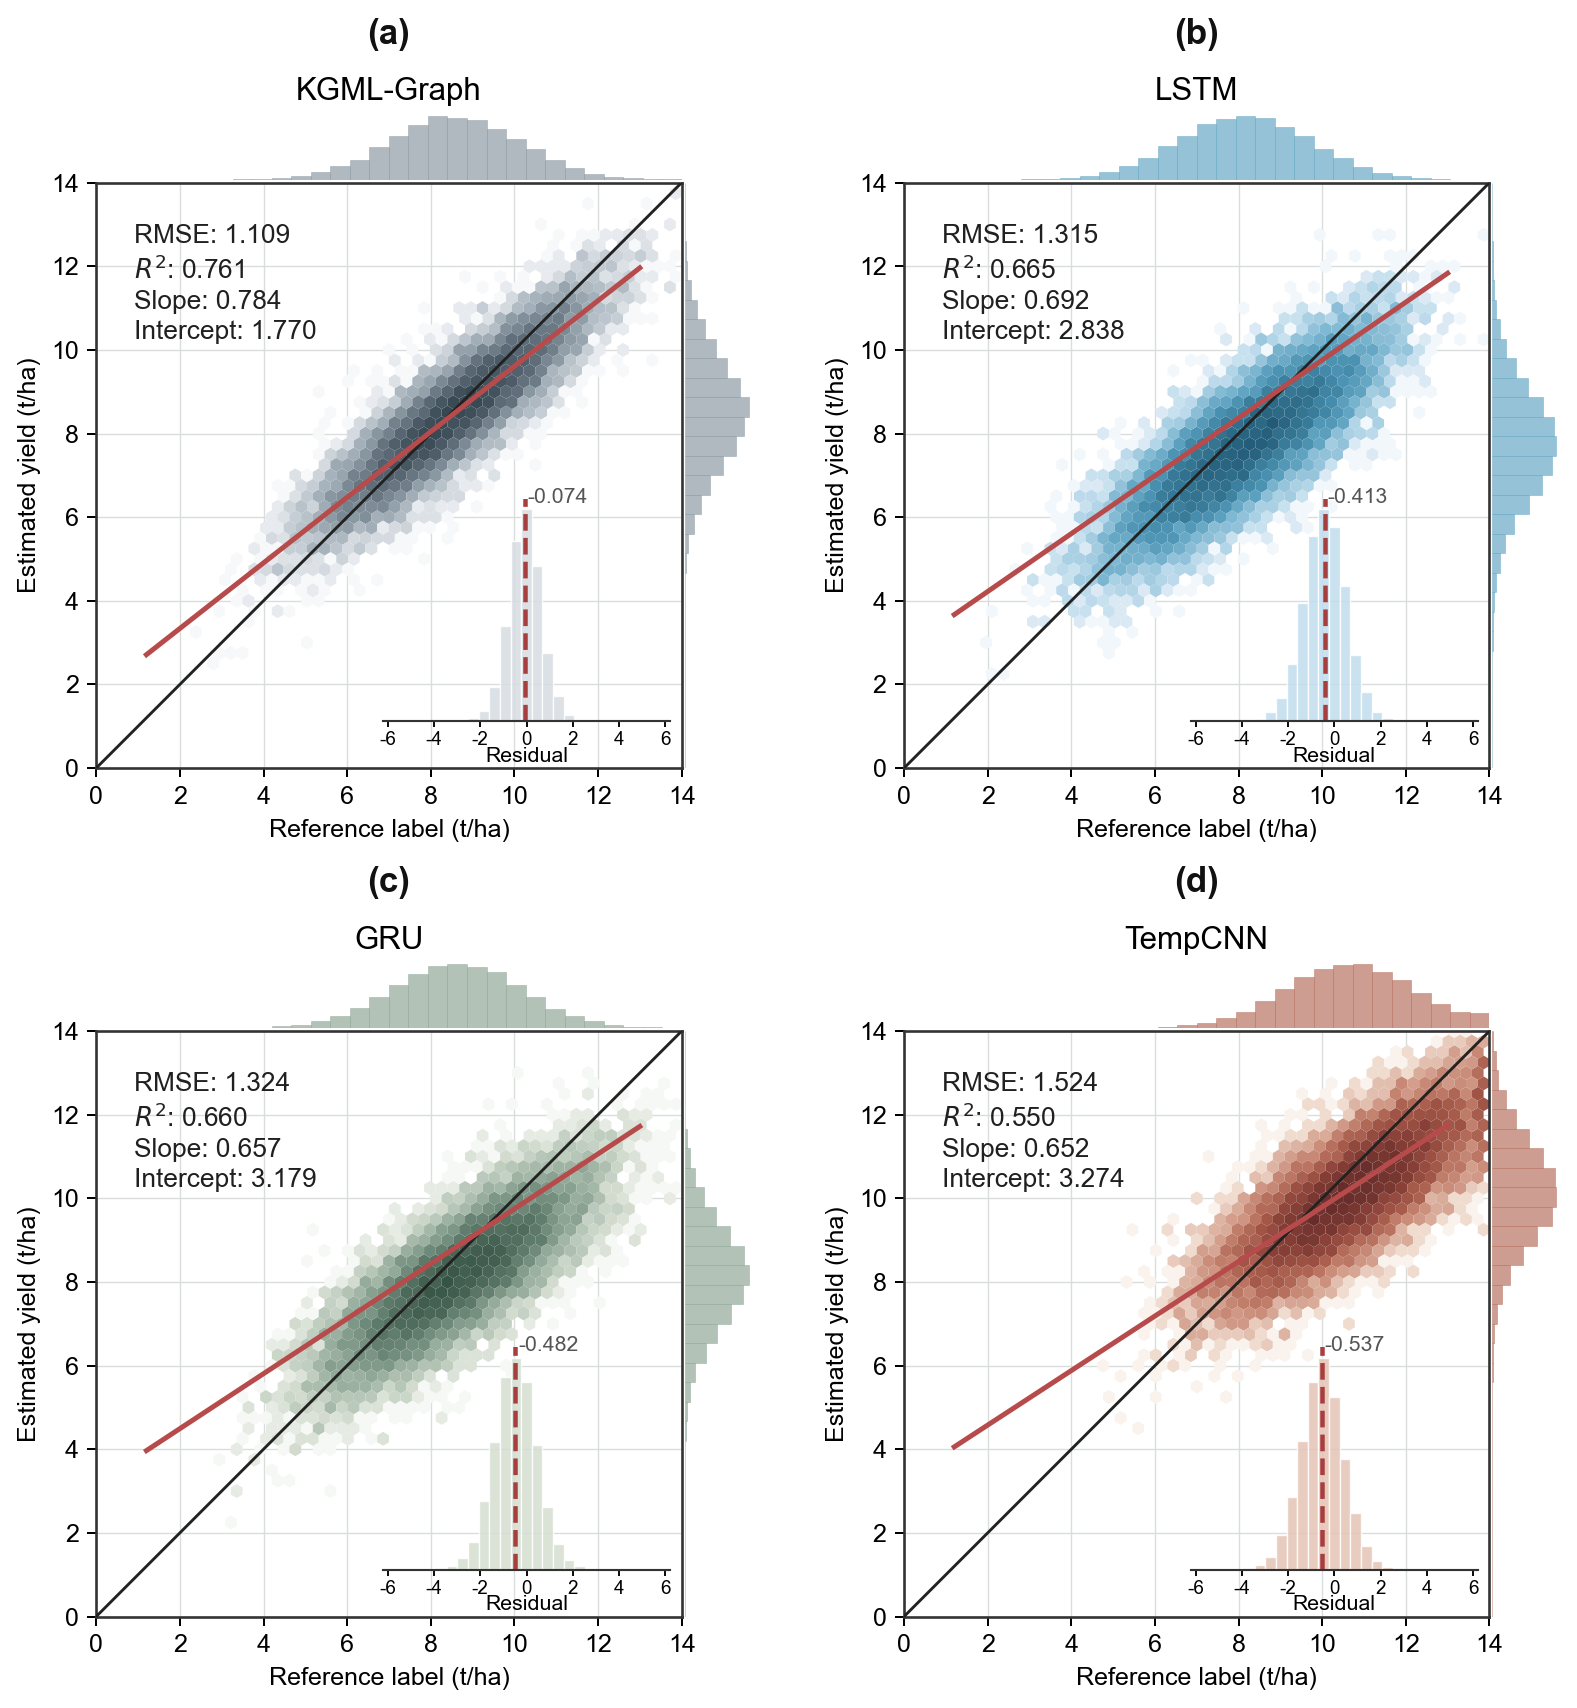

In [7]:
fig = plt.figure(
    figsize=(9.0, 9.0),
    dpi=180,
)

gs = fig.add_gridspec(
    2,
    2,
    left=0.075,
    right=0.935,
    bottom=0.075,
    top=0.965,
    wspace=0.38,
    hspace=0.43,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for i, (ax, label, params) in enumerate(
    zip(axes, panel_labels, MODELS)
):
    MARGINAL_COLOR = colors[i][5]
    RESID_COLOR = colors[i][2]
    HEXBIN_CMAP = LinearSegmentedColormap.from_list(
        name="my_cmap",
        colors=colors[i],
        N=256
    )

    plot_panel(
        ax,
        *params,
        cmap=HEXBIN_CMAP,
        seed=100 + i,
    )

    ax.text(
        0.5,
        1.225,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        color="#111111",
    )


fig.savefig(
    "HEXBIN1.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
)
plt.show()